# Dust and gas maps

Documentation on dust maps: https://dustmaps.readthedocs.io/en/latest/installation.html

More info on dust maps: http://argonaut.skymaps.info/usage

This tutorial gets E(B-V) from dust maps stored locally and converts the E(B-V) to Av.

- One can download the maps and query locally,
- It is possible to search just one coordinate,
- Or to create a grid and get a map.



In [1]:
from astropy.coordinates import SkyCoord
import astropy.units as units
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.skyview import SkyView
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

#local dust maps
from dustmaps.bayestar import BayestarQuery

# wb based dust maps
from dustmaps.sfd import SFDWebQuery
from dustmaps.bayestar import BayestarWebQuery


In [3]:
# define the path to the dust maps on the local computer
# the dust_maps directory has the bayestar directory that contains the relevant dist map
# dust_maps/bayestar/bayestar2019.h5

from dustmaps.config import config
config['data_dir'] = '/Users/denes/Teaching/Astrophysical_objects/Tutorials/dust_maps/'


In [6]:
# query for one position

#bayestar = BayestarQuery(version='bayestar2019') # 'bayestar2019' is the default
#coords = SkyCoord(73.*units.deg, 3.*units.deg, distance=1000.*units.pc, frame='galactic')
 
#reddening = bayestar(coords, mode='median')
#print(reddening)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 42.524 s
  pix_info:   0.595 s
   samples:  29.056 s
      best:   5.161 s
       nan:   0.580 s
      sort:   6.902 s
       idx:   0.230 s
0.25


## Plotting maps

example from:
https://dustmaps.readthedocs.io/en/latest/examples.html

In [25]:
# let's define the coordinate grid for the map

ra0, dec0 = (73., 3.)
ra = np.arange(ra0 - 5., ra0 + 5., 0.05)
dec = np.arange(dec0 - 5., dec0 + 5., 0.05)
ra, dec = np.meshgrid(ra, dec)
coords_1 = SkyCoord(ra*units.deg, dec*units.deg,
                  distance=1.*units.kpc, frame='icrs')

In [26]:
# get the data for the whole grid

bayestar = BayestarQuery(max_samples=1)
Av_bayestar = 2.742 * bayestar(coords_1)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 18.823 s
  pix_info:   0.557 s
   samples:   5.100 s
      best:   5.480 s
       nan:   0.050 s
      sort:   7.483 s
       idx:   0.153 s


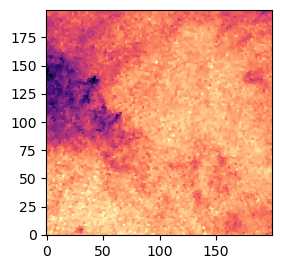

In [27]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
plt.imshow(Av_bayestar, cmap='magma_r')
ax1.invert_yaxis()

In [18]:
Av_bayestar.shape

(200, 200)

In [29]:
# get HI column denisty map for the same region of the sky

c = SkyCoord(ra=ra0 * u.degree, dec=dec0 * u.degree, frame='icrs')

path = SkyView.get_images(position=c, width=10*u.deg, height=10*u.deg, survey=['HI4PI'], pixels=[200,200])

hdulist_HI = path[0]
d_HI = hdulist_HI[0].data
h_HI = hdulist_HI[0].header

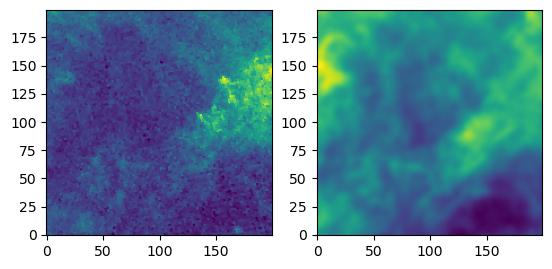

In [32]:
Av2 = Av_bayestar[:, ::-1]

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
plt.imshow(Av2)
ax1.invert_yaxis()

ax2 = fig.add_subplot(1,2,2)
plt.imshow(d_HI)
ax2.invert_yaxis()

plt.show()

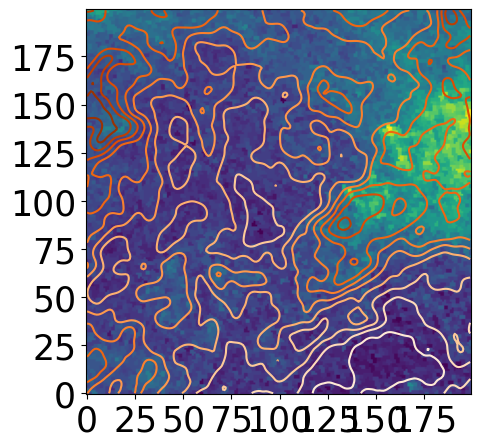

In [33]:
# making an overlay

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
ax.imshow(Av2)
ax.contour(d_HI, levels=10, cmap='Oranges')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.invert_yaxis()
plt.show()

(array([ 256.,  356.,  900., 5124., 4557., 4771., 4199., 6594., 2191.,
        1737., 1601., 2365.,  767.,  624.,  508.,  871.,  346.,  320.,
         614.,  263.,  200.,  206.,  298.,  144.,   43.,   47.,   68.,
          16.,    0.,   14.]),
 array([0.      , 0.034732, 0.069464, 0.104196, 0.138928, 0.17366 ,
        0.208392, 0.243124, 0.277856, 0.312588, 0.34732 , 0.382052,
        0.416784, 0.451516, 0.486248, 0.52098 , 0.555712, 0.590444,
        0.625176, 0.659908, 0.69464 , 0.729372, 0.764104, 0.798836,
        0.833568, 0.8683  , 0.903032, 0.937764, 0.972496, 1.007228,
        1.04196 ], dtype=float32),
 <BarContainer object of 30 artists>)

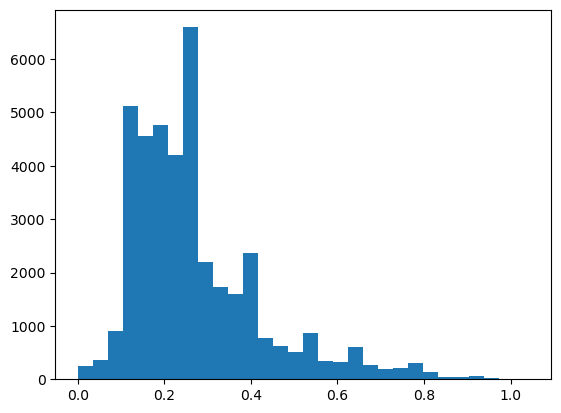

In [41]:
plt.hist(Av2.flatten(), bins=30)


(array([ 683.,  601.,  493.,  621.,  450.,  693., 1136., 1308., 1541.,
        2919., 2989., 3025., 2407., 2635., 2972., 2694., 2320., 1812.,
        2500., 2424., 1321.,  973.,  451.,  301.,  196.,  160.,  134.,
         143.,   68.,   30.]),
 array([3.3875872e+20, 3.7394711e+20, 4.0913545e+20, 4.4432384e+20,
        4.7951219e+20, 5.1470057e+20, 5.4988892e+20, 5.8507730e+20,
        6.2026565e+20, 6.5545403e+20, 6.9064241e+20, 7.2583073e+20,
        7.6101911e+20, 7.9620749e+20, 8.3139588e+20, 8.6658419e+20,
        9.0177257e+20, 9.3696095e+20, 9.7214934e+20, 1.0073377e+21,
        1.0425260e+21, 1.0777144e+21, 1.1129028e+21, 1.1480912e+21,
        1.1832796e+21, 1.2184679e+21, 1.2536562e+21, 1.2888446e+21,
        1.3240330e+21, 1.3592214e+21, 1.3944097e+21], dtype=float32),
 <BarContainer object of 30 artists>)

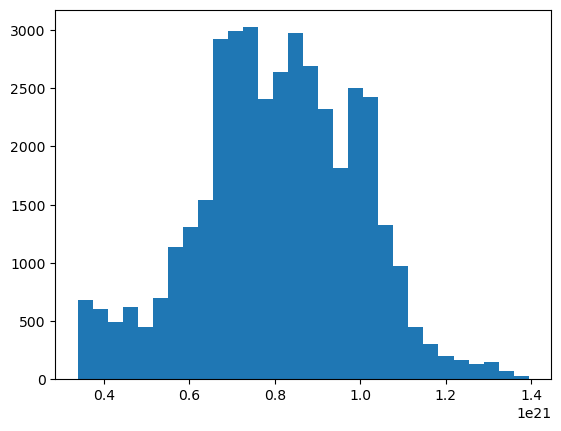

In [42]:
plt.hist(d_HI.flatten(), bins=30)

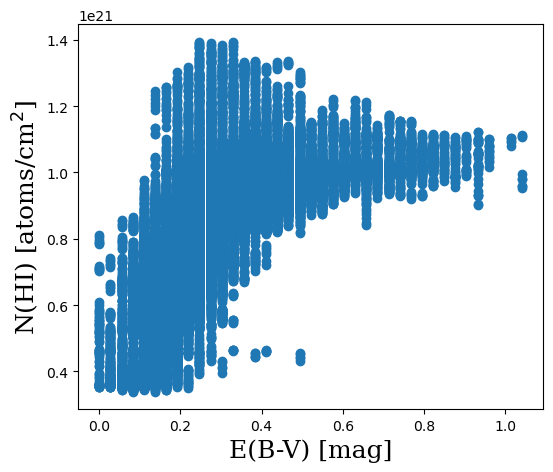

In [34]:
# directly compare the E(B-V) to N(HI) in each pixel

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(Av2, d_HI)
ax.set_xlabel('E(B-V) [mag]', size=18,family='serif')
ax.set_ylabel(r'N(HI) [atoms/cm$^2$]', size=18,family='serif')
plt.show()

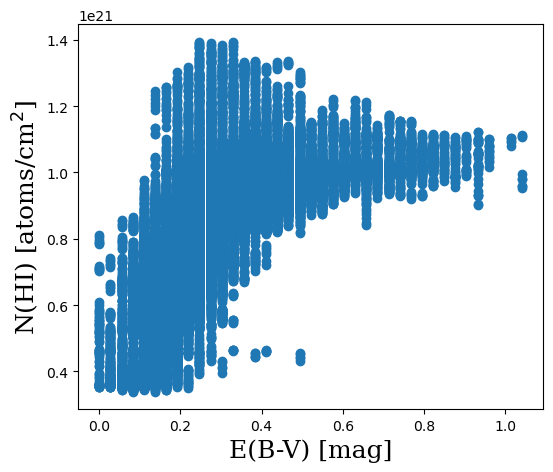

In [45]:
# directly compare the E(B-V) to N(HI) in each pixel

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(Av2.flatten(), d_HI.flatten())
ax.set_xlabel('E(B-V) [mag]', size=18,family='serif')
ax.set_ylabel(r'N(HI) [atoms/cm$^2$]', size=18,family='serif')
plt.show()

In [48]:
coef = np.polyfit(Av2.flatten(), d_HI.flatten(), 1)
print(coef)

[8.11554112e+20 5.86470809e+20]


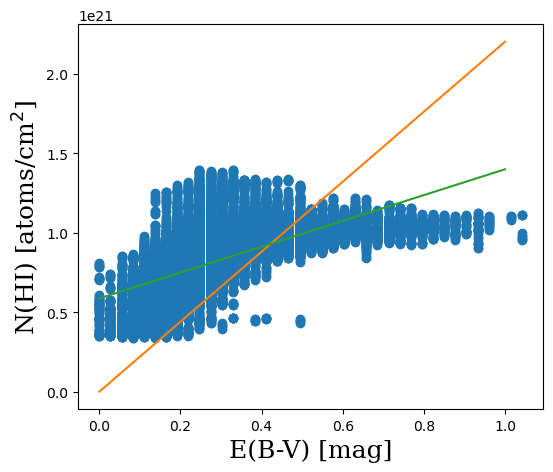

In [52]:
# lets add a model from a scientic paper
# relation from Güver and Özel 2009 (doi:10.1111/j.1365-2966.2009.15598.x)

ebv_range = np.arange(np.min(Av2), np.max(Av2), 0.1)
line = ebv_range * 2.2 * 10**21
line2 = ebv_range * 8.11554112e+20  + 5.86470809e+20

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(Av2, d_HI)
plt.plot(ebv_range, line, color='C1')
plt.plot(ebv_range, line2, color='C2')
ax.set_xlabel('E(B-V) [mag]', size=18,family='serif')
ax.set_ylabel(r'N(HI) [atoms/cm$^2$]', size=18,family='serif')
plt.show()

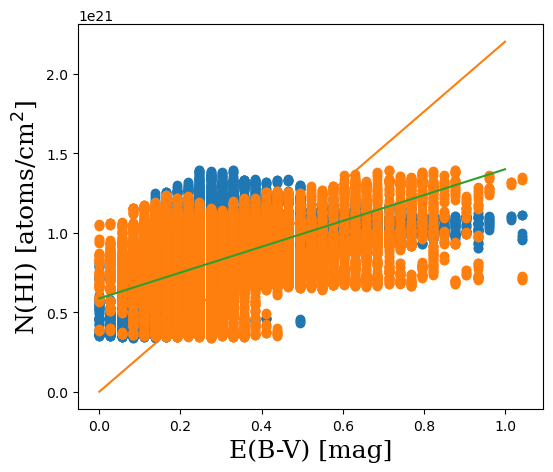

In [55]:
ebv_range = np.arange(np.min(Av2), np.max(Av2), 0.1)
line = ebv_range * 2.2 * 10**21
line2 = ebv_range * 8.11554112e+20  + 5.86470809e+20

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(Av2.flatten(), d_HI.flatten())
plt.scatter(Av_bayestar.flatten(), d_HI.flatten())
plt.plot(ebv_range, line, color='C1')
plt.plot(ebv_range, line2, color='C2')
ax.set_xlabel('E(B-V) [mag]', size=18,family='serif')
ax.set_ylabel(r'N(HI) [atoms/cm$^2$]', size=18,family='serif')
plt.show()

## Disk 

In [57]:
# let's define the coordinate grid for the map

ra0, dec0 = (287., 3.)
ra = np.arange(ra0 - 5., ra0 + 5., 0.05)
dec = np.arange(dec0 - 5., dec0 + 5., 0.05)
ra, dec = np.meshgrid(ra, dec)
coords_2 = SkyCoord(ra*units.deg, dec*units.deg,
                  distance=1.*units.kpc, frame='icrs')

In [58]:
# get the data for the whole grid

bayestar = BayestarQuery(max_samples=1)
Av_bayestar_d = 2.742 * bayestar(coords_2)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 24.759 s
  pix_info:   0.718 s
   samples:   9.862 s
      best:   6.405 s
       nan:   0.216 s
      sort:   7.374 s
       idx:   0.184 s


In [60]:
# get HI column denisty map for the same region of the sky

c = SkyCoord(ra=ra0 * u.degree, dec=dec0 * u.degree, frame='icrs')

path = SkyView.get_images(position=c, width=10*u.deg, height=10*u.deg, survey=['HI4PI'], pixels=[200,200])

hdulist_HI = path[0]
d_HI_2 = hdulist_HI[0].data
h_HI_2 = hdulist_HI[0].header

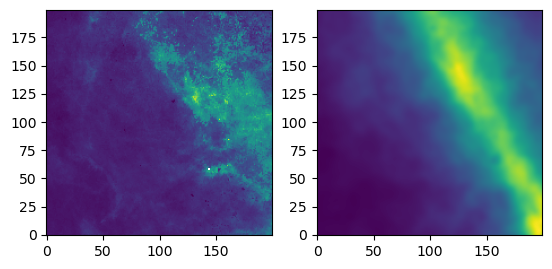

In [64]:
Av2_d = Av_bayestar_d[:, ::-1]

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
plt.imshow(Av2_d)
ax1.invert_yaxis()

ax2 = fig.add_subplot(1,2,2)
plt.imshow(d_HI_2)
ax2.invert_yaxis()

plt.show()

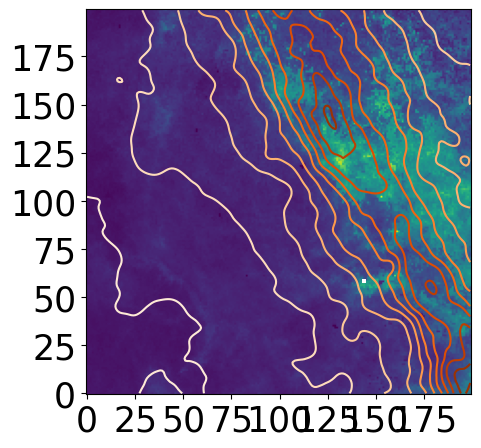

In [65]:
# making an overlay

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
ax.imshow(Av2_d)
ax.contour(d_HI_2, levels=10, cmap='Oranges')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.invert_yaxis()
plt.show()

In [69]:
coef = np.polyfit(Av2_d.flatten(), d_HI_2.flatten(), 1)
print(coef)

LinAlgError: SVD did not converge in Linear Least Squares

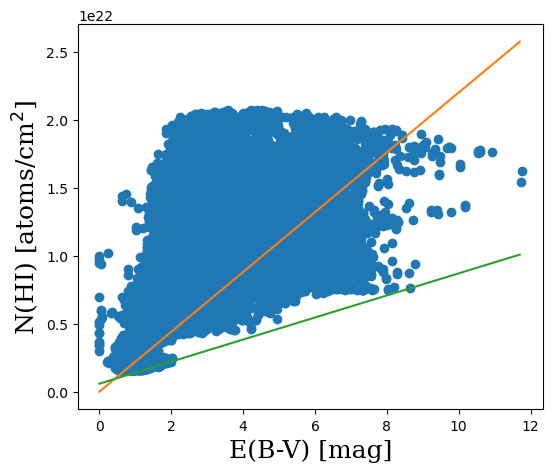

In [68]:
# lets add a model from a scientic paper
# relation from Güver and Özel 2009 (doi:10.1111/j.1365-2966.2009.15598.x)

ebv_range = np.arange(np.nanmin(Av2_d), np.nanmax(Av2_d), 0.1)
line = ebv_range * 2.2 * 10**21
line2 = ebv_range * 8.11554112e+20  + 5.86470809e+20

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(Av2_d, d_HI_2)
plt.plot(ebv_range, line, color='C1')
plt.plot(ebv_range, line2, color='C2')
ax.set_xlabel('E(B-V) [mag]', size=18,family='serif')
ax.set_ylabel(r'N(HI) [atoms/cm$^2$]', size=18,family='serif')
plt.show()